<a href="https://colab.research.google.com/github/krishna-gunda/Food_classification_using_Deeplearning/blob/main/Resnet_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/final_dataset.zip" -d /content/

In [ ]:
train_path='/content/train'
val_path='/content/val'

**resnet**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,MaxPool2D,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model

In [ ]:
#preprocessing image
train=ImageDataGenerator(rescale=1/255,rotation_range=20,shear_range=0.2,
                         zoom_range=0.2,horizontal_flip=True)
val=ImageDataGenerator(rescale=1/255)


In [ ]:
resnet_train=train.flow_from_directory(train_path,target_size=(255,255),
                                      batch_size=32,class_mode='categorical')
resnet_val=val.flow_from_directory(val_path,target_size=(255,255),
                                      batch_size=32,class_mode='categorical')

Found 7779 images belonging to 34 classes.
Found 1947 images belonging to 34 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50

resnet50=ResNet50(weights='imagenet',include_top=False,input_shape=(255,255,3))

for i in resnet50.layers:
  i.trainable = False





94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
Flatten_values=Flatten()(resnet50.output)

h1_out = Dense(units=128,kernel_initializer='he_uniform',activation='relu')(Flatten_values)
h2_out = Dense(units=64,kernel_initializer='he_uniform',activation='relu')(h1_out)
h3_out = Dense(units=32,kernel_initializer='he_uniform',activation='relu')(h2_out)
output = Dense(units=34,kernel_initializer='glorot_uniform',activation='softmax')(h3_out)

model = Model(inputs = resnet50.input , outputs = output)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 261, 261,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 40,376,514 (154.02 MB)

 Trainable params: 16,788,802 (64.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(optimizer='adam',loss = 'categorical_crossentropy',metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
print(len(resnet_train))
print(len(resnet_val))

244
61


In [ ]:
x, y = next(iter(resnet_train))

print(x.shape)
print(y.shape)

(32, 255, 255, 3)
(32, 34)


In [ ]:



from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history = model.fit(resnet_train,
    validation_data=resnet_val,
    epochs=10,
    callbacks=[early_stop]
)



best_epoch = np.argmin(history.history['val_loss']) + 1

best_val_loss = min(history.history['val_loss'])

best_val_accuracy = max(history.history['val_accuracy'])

print(f"\nBest Epoch : {best_epoch}")
print(f"Best Validation Loss : {best_val_loss:.4f}")
print(f"Best Validation Accuracy : {best_val_accuracy*100:.2f}%")

# ==============================
# SAVE MODEL
# ==============================
model.save("food_classification_custom_Resnetmodel.keras")

print("\nModel Saved Successfully!")


# Evaluate model

loss, accuracy = model.evaluate(resnet_val)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

Epoch 1/10
186/244 ━━━━━━━━━━━━━━━━━━━━ 45s 791ms/step - accuracy: 0.0407 - loss: 3.5959

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


244/244 ━━━━━━━━━━━━━━━━━━━━ 238s 912ms/step - accuracy: 0.0488 - loss: 3.5069 - val_accuracy: 0.0621 - val_loss: 3.4059
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 234s 830ms/step - accuracy: 0.0674 - loss: 3.3971 - val_accuracy: 0.0693 - val_loss: 3.3724
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 199s 817ms/step - accuracy: 0.0721 - loss: 3.3511 - val_accuracy: 0.0755 - val_loss: 3.3236
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 209s 858ms/step - accuracy: 0.0803 - loss: 3.3143 - val_accuracy: 0.0976 - val_loss: 3.2746
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 203s 831ms/step - accuracy: 0.0910 - loss: 3.2855 - val_accuracy: 0.0971 - val_loss: 3.2464
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 202s 826ms/step - accuracy: 0.0931 - loss: 3.2520 - val_accuracy: 0.1043 - val_loss: 3.2097
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 200s 818ms/step - accuracy: 0.1045 - loss: 3.2246 - val_accuracy: 0.0950 - val_loss: 3.2063
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 200s 820ms/step - accuracy: 0.1066 - loss: 3.21

In [ ]:
# class mapping (must exist from training)
class_indices = resnet_val.class_indices

# reverse mapping
index_to_class = {v: k for k, v in class_indices.items()}

Saving download (4).jpeg to download (4).jpeg


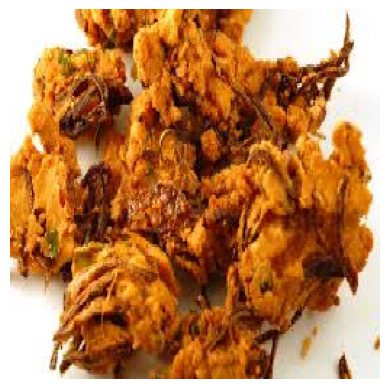

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Class: pakode
Confidence: 88.22711


In [ ]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(255,255))
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class_index = np.argmax(prediction)
predicted_class_name = index_to_class[predicted_class_index]

print("Predicted Class:", predicted_class_name)
print("Confidence:", np.max(prediction)*100)

In [ ]:
resnet_val.class_indices

{'Baked Potato': 0,
 'Crispy Chicken': 1,
 'Donut': 2,
 'Fries': 3,
 'Hot Dog': 4,
 'Sandwich': 5,
 'Taco': 6,
 'Taquito': 7,
 'apple_pie': 8,
 'burger': 9,
 'butter_naan': 10,
 'chai': 11,
 'chapati': 12,
 'cheesecake': 13,
 'chicken_curry': 14,
 'chole_bhature': 15,
 'dal_makhani': 16,
 'dhokla': 17,
 'fried_rice': 18,
 'ice_cream': 19,
 'idli': 20,
 'jalebi': 21,
 'kaathi_rolls': 22,
 'kadai_paneer': 23,
 'kulfi': 24,
 'masala_dosa': 25,
 'momos': 26,
 'omelette': 27,
 'paani_puri': 28,
 'pakode': 29,
 'pav_bhaji': 30,
 'pizza': 31,
 'samosa': 32,
 'sushi': 33}

In [ ]:
resnet_val.classes

array([ 0,  0,  0, ..., 33, 33, 33], dtype=int32)

In [ ]:
# Metrics calculation

import tensorflow as tf
import numpy as np
import json
import os

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#load the model

model = load_model("food_classification_custom_Resnetmodel.keras")

print("Model Loaded Successfully")


y_true = resnet_val.classes #resent_val variable called from the above image processing


predictions = model.predict(resnet_val)


y_pred = np.argmax(predictions, axis=1)

# accuracy
accuracy = accuracy_score(y_true, y_pred)

#precision

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)


# Confusion matrix


cm = confusion_matrix(y_true, y_pred)

#classification report

class_report = classification_report(
    y_true,
    y_pred,
    target_names=resnet_val.class_indices.keys(),
    output_dict=True
)




print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")



# SAVE METRICS TO JSON


results = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "confusion_matrix": cm.tolist(), # cm is result of confusion matrics that we are converting to list
    "classification_report": class_report
}

with open("model_evaluation_resnet_results.json", "w") as json_file:
    json.dump(results, json_file, indent=4)

print("Metrics Saved Successfully to JSON File")


Model Loaded Successfully
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 387ms/step
Accuracy  : 0.0262
Precision : 0.0206
Metrics Saved Successfully to JSON File


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m